In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("CPIndex_Jan13-To-Jan25.csv")
df

,Year,Month,State,Group,Sub Group,Description,Rural,Urban,Combined,Status
0,2013,January,ALL India,1.0,NaN,Food and beverages,105.5,105.9,105.6,F
1,2013,February,ALL India,1.0,NaN,Food and beverages,106.3,107.2,106.6,F
2,2013,March,ALL India,1.0,NaN,Food and beverages,106.6,107.3,106.9,F
3,2013,April,ALL India,1.0,NaN,Food and beverages,107.1,108.8,107.7,F
4,2013,May,ALL India,1.0,NaN,Food and beverages,108.1,111.1,109.2,F
...,...,...,...,...,...,...,...,...,...,...
34434,2024,September,West Bengal,NaN,NaN,General Index (All Groups),200.6,195.0,198.0,F
34435,2024,October,West Bengal,NaN,NaN,General Index (All Groups),204.3,198.0,201.3,F
34436,2024,November,West Bengal,NaN,NaN,General Index (All Groups),203.6,197.6,200.8,F
34437,2024,December,West Bengal,NaN,NaN,General Index (All Groups),201.9,195.1,198.7,F


In [ ]:
df.drop(columns=["group","class", "sub_class", "item"], inplace=True)
df[["year","month","state", "inflation"]]

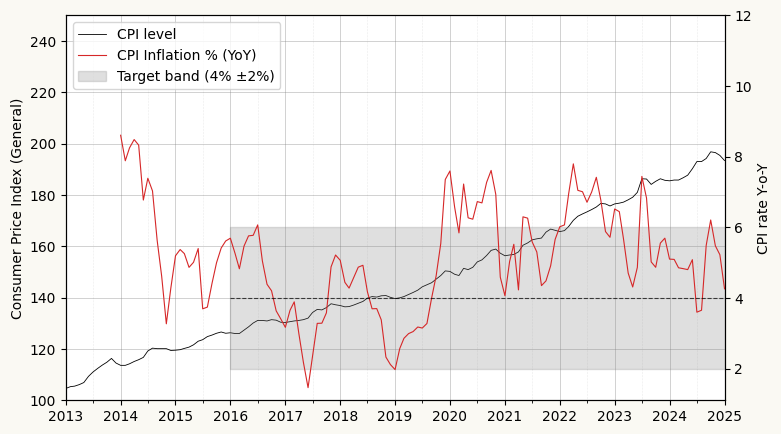

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import matplotlib.dates as mdates


df = pd.read_csv("CPIndex_Jan13-To-Jan25.csv")


monthOrder = CategoricalDtype( ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], ordered=True)
df["Month"] = df["Month"].astype(monthOrder)
df.sort_values(by=["State","Description", "Year", "Month"], inplace=True)
filter = (df["Description"] == "General Index (All Groups)") & (df["State"] == "ALL India")
df_cpi = df[filter].copy()


df_cpi["date"] = df_cpi["Month"].astype("str") + "-" + df_cpi["Year"].astype("str")
df_cpi["Month-Year"] = pd.to_datetime(df_cpi["date"], format= '%B-%Y')



# Plotting code
fig, axs = plt.subplots(figsize=(8.5,5),facecolor="#FAF9F3")
axs.plot("Month-Year", "Combined", data = df_cpi, color="0", label = "CPI level", linewidth = 0.6)


#axs.set_xlabel("Month-Year")
axs.set_ylabel("Consumer Price Index (General)")


axs.xaxis.set_major_locator(mdates.YearLocator())
axs.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1,7])) 


#axs.tick_params(axis="x", rotation = 45) 


axs.grid(which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
axs.grid(which='minor', linestyle=':', linewidth=0.4, color='gray', alpha=0.3)


df_cpi["cpi rate"] = (df_cpi["Combined"] - df_cpi["Combined"].shift(periods=12)) / df_cpi["Combined"].shift(periods=12)*100


axs2  = axs.twinx()
axs2.set_ylabel("CPI rate Y-o-Y")
axs2.plot(df_cpi["Month-Year"], df_cpi["cpi rate"],color="tab:red", label = "CPI Inflation % (YoY)", linewidth = 0.8)


axs.set_ylim(top=250)
axs2.set_ylim(top=12)

axs.set_xlim(df_cpi["Month-Year"].min(), df_cpi["Month-Year"].max())

xmin, xmax = axs.get_xlim()                       # float date-numbers of the axis
target = mdates.date2num(pd.Timestamp('2016-01-01'))
x0 = (target - xmin) / (xmax - xmin)
x1 = 1.0

axs2.fill_betweenx([2, 6], pd.Timestamp('2016-01-01 00:00:00'), pd.Timestamp('2025-01-01 00:00:00'),  color = "grey", alpha = 0.25, label="Target band (4% ±2%)")
axs2.axhline(4,x0, x1,  color = "0", linestyle = "--", linewidth = 0.8, alpha =0.7)

#axs2.axhline(df_cpi["cpi rate"].mean(), linestyle = "--", linewidth = 1, color='0', alpha =0.8)


line1, label1 = axs.get_legend_handles_labels()
line2, label2 = axs2.get_legend_handles_labels()
axs.legend(line1+line2, label1+label2, loc="upper left")



# x0 = df_cpi["Month-Year"].between(pd.Timestamp('2013-01-01 00:00:00'), pd.Timestamp('2016-01-01 00:00:00'), inclusive="left").sum()/(df_cpi["Month-Year"].count()-1)


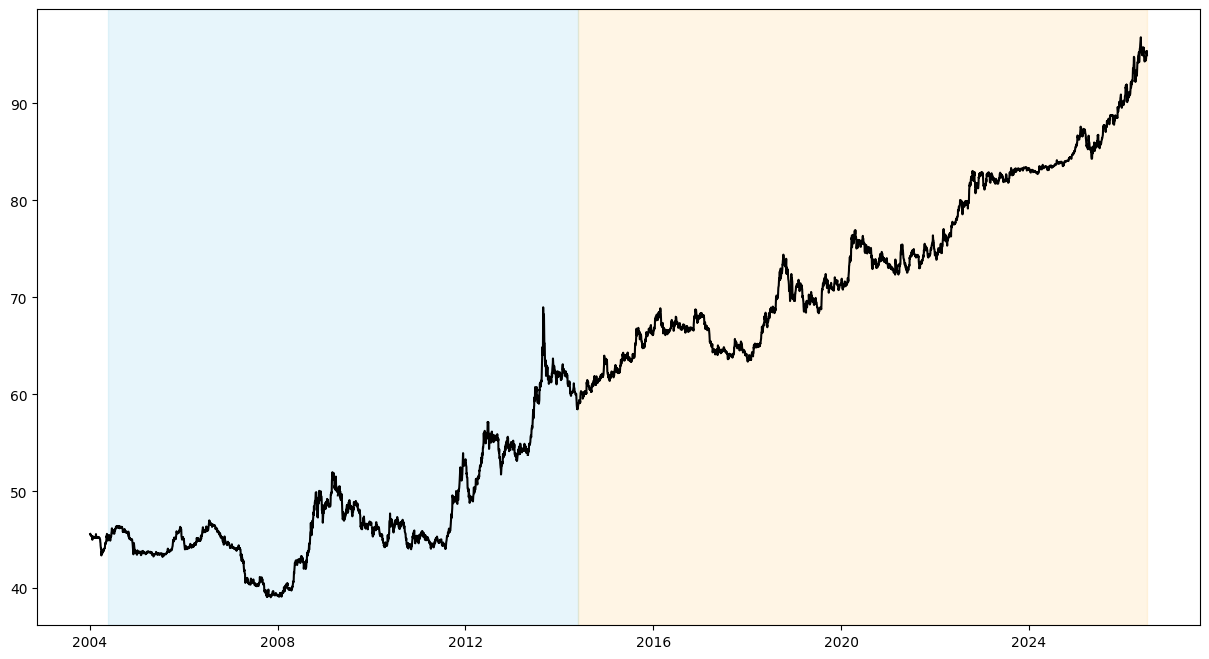

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_ex = pd.read_csv("https://stats.bis.org/api/v2/data/dataflow/BIS/WS_XRU/1.0/D.IN.INR.A?format=csv")
df_ex.drop(columns=["FREQ", "REF_AREA", "CURRENCY", "COLLECTION", "UNIT_MULT", "DECIMALS", "AVAILABILITY", "TITLE", "OBS_PRE_BREAK", "OBS_CONF", "OBS_STATUS"], inplace=True)
df_ex["TIME_PERIOD"] = pd.to_datetime(df_ex["TIME_PERIOD"], format="%Y-%m-%d")
df_ex.sort_values(by="TIME_PERIOD", inplace=True)

fig, ax = plt.subplots(figsize = (15,8))

filter = df_ex["TIME_PERIOD"] >= pd.to_datetime("2004-01-05", format= "%Y-%m-%d")

#ax.plot(df_ex["TIME_PERIOD"], df_ex["OBS_VALUE"])

ax.plot(df_ex[filter]["TIME_PERIOD"], df_ex[filter]["OBS_VALUE"], color = "0")


ax.axvspan(pd.to_datetime("2004-05-22"), pd.to_datetime("2014-05-26"), color = "skyblue", alpha= 0.2)
ax.axvspan(pd.to_datetime("2014-05-26"), pd.to_datetime("2026-07-07"), color = "orange", alpha= 0.1)




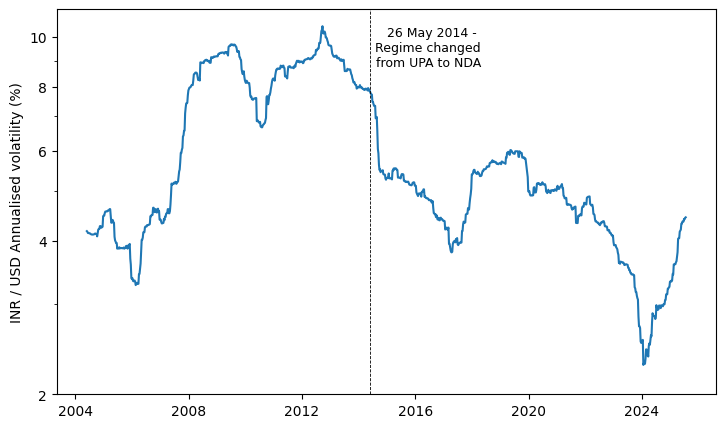

In [8]:

import matplotlib.ticker as mticker
import matplotlib.dates as mdates


s = df_ex.set_index("TIME_PERIOD")
weekly = s["OBS_VALUE"].resample("W-FRI").last()

log_ret = np.log(weekly).diff()


weekly_vol = log_ret.rolling(window=104, center=True).std()*np.sqrt(52)

out = pd.DataFrame({"close":weekly ,
                    "weekly return":log_ret,
                    "vol": weekly_vol})


out = out.loc["2004-05-22 00:00:00":"2026-05-26 00:00:00"].copy()


fig,ax = plt.subplots(figsize = (8.5,5))
ax.plot(out.index, out["vol"]*100)
ax.set_yscale("log")
ax.set_yticks([2, 4, 6, 8, 10])


#ax.xaxis.set_major_locator(mdates.YearLocator())
ax.text(pd.to_datetime("2018-04-26"), 10.5,
        "26 May 2014 - \n Regime changed\nfrom UPA to NDA",
        rotation=0, va="top", ha="right", fontsize=9)

ax.yaxis.set_major_formatter(mticker.ScalarFormatter())  # plain numbers, not 10^x
ax.yaxis.set_minor_formatter(mticker.NullFormatter())   

ax.set_ylabel("INR / USD Annualised volatility (%)")

ax.axvline(pd.to_datetime("2014-05-26"), ls = "--", color= "0", linewidth = 0.6)